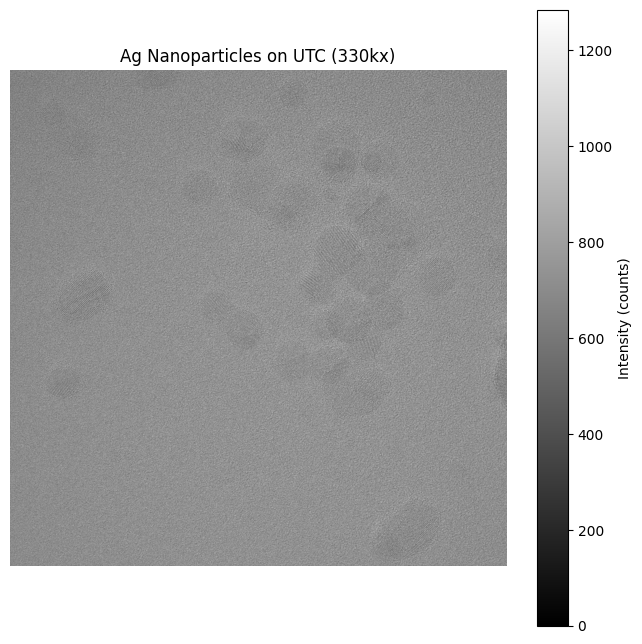

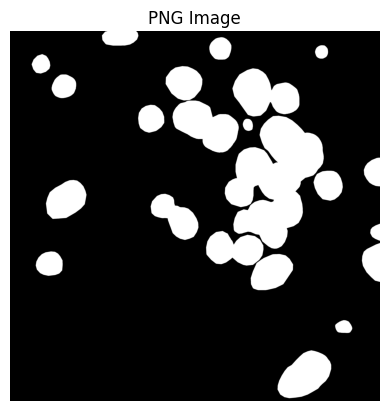

In [3]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off') 
plt.show()


img = mpimg.imread(label_file)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [6]:
from skimage.util import view_as_windows

def split_patches(patch_size, image, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [7]:
patches = split_patches(16, image_data, 8)

In [8]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(400, 700),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)
    return dgms, vectors

dgms, vectorised_patches = PH_patch(patches)


KeyboardInterrupt: 

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_261109/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


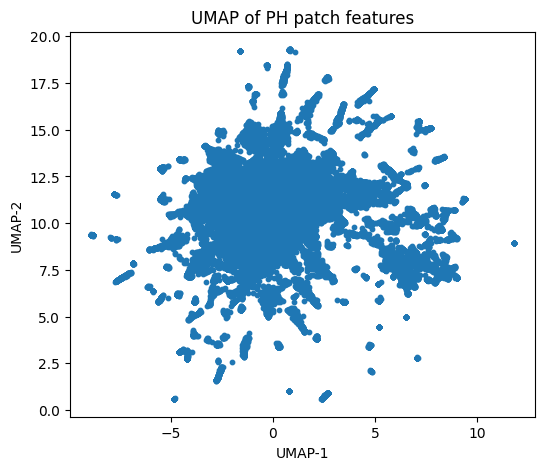

In [5]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

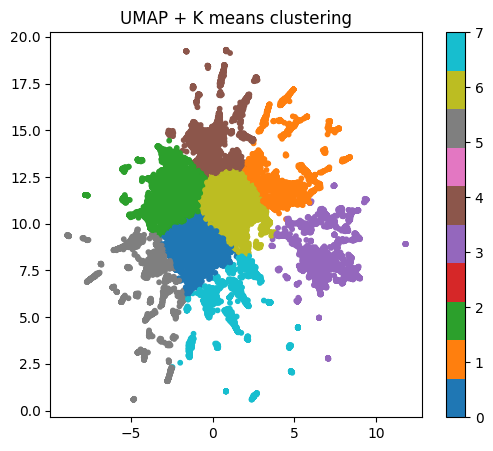

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42)
labels = kmeans.fit_predict(embedding)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=labels,
    cmap="tab10",
    s=10
)
plt.title("UMAP + K means clustering")
plt.colorbar()
plt.show()

In [ ]:
from skimage.util import view_as_windows

def get_positions(image_data, patch_size=16, stride=None):
    if stride is None:
        stride = patch_size

    blocks = view_as_windows(
        image_data,
        (patch_size, patch_size),
        step=stride
    )

    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * stride, j * stride)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [ ]:
import numpy as np

def label_to_image(original_image, labels, positions, patch_size=16, n_clusters=None):
    H, W = original_image.shape[:2]

    if n_clusters is None:
        n_clusters = np.max(labels) + 1

    votes = np.zeros((H, W, n_clusters), dtype=np.float32)

    for (r, c), lab in zip(positions, labels):
        votes[r:r+patch_size, c:c+patch_size, lab] += 1

    return np.argmax(votes, axis=-1)

In [9]:
positions = get_positions(image_data)
label_img = label_to_image(image_data, labels, positions)

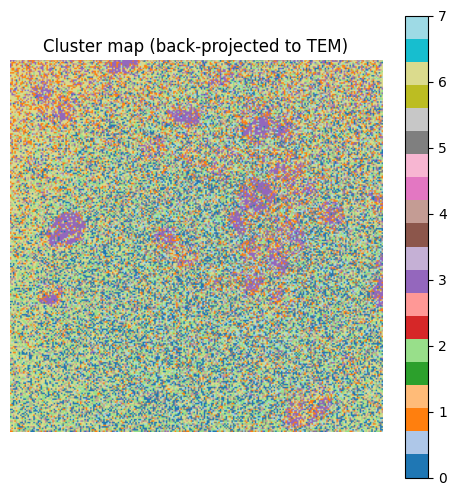

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

In [12]:
cluster_patches = {}
for c in np.unique(labels):
    cluster_patches[c] = patches[labels == c]

In [13]:
def patch_fft(patch):
    patch = patch - np.mean(patch)
    f = np.fft.fft2(patch)
    fshift = np.fft.fftshift(f)
    return np.log1p(np.abs(fshift))

cluster_ffts = {}
for c, patches_in_c in cluster_patches.items():
    ffts = np.array([patch_fft(p) for p in patches_in_c])
    cluster_ffts[c] = np.mean(ffts, axis=0)  # representative FFT

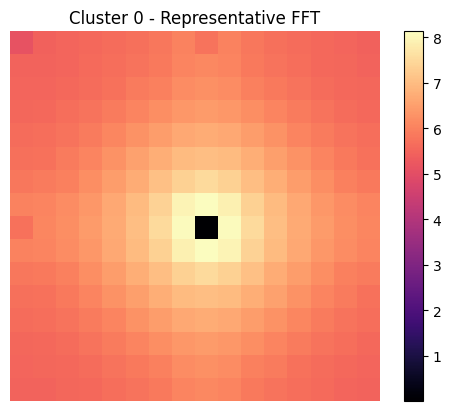

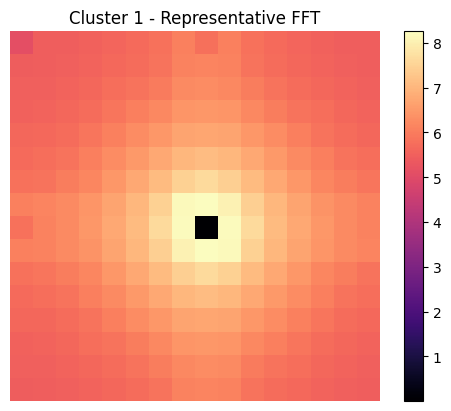

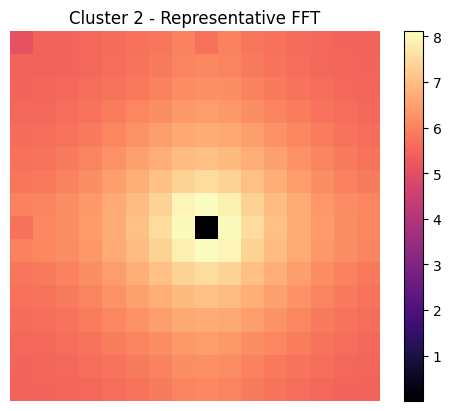

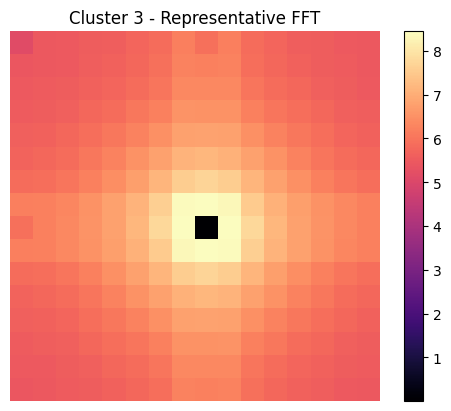

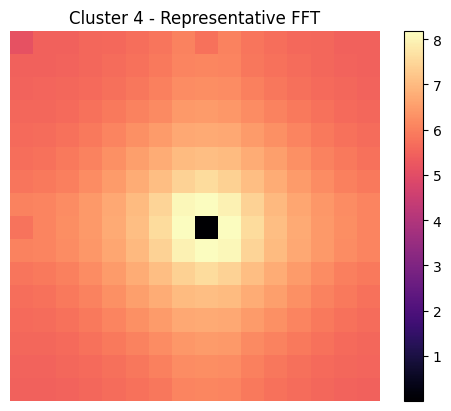

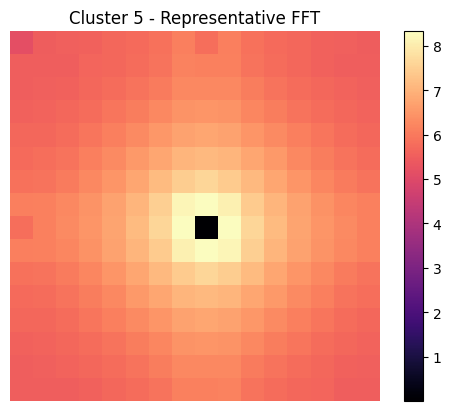

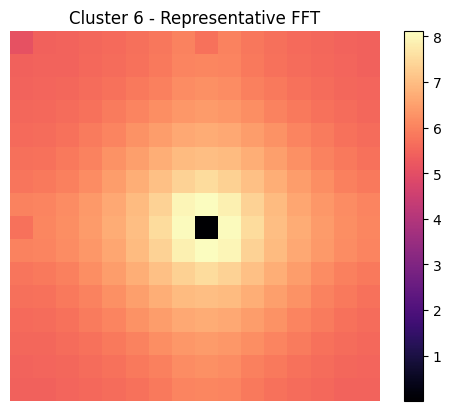

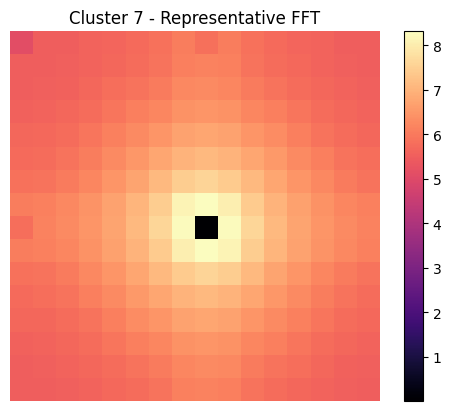

In [14]:
for c, fft_img in cluster_ffts.items():
    plt.figure()
    plt.title(f"Cluster {c} - Representative FFT")
    plt.imshow(fft_img, cmap='magma')
    plt.colorbar()
    plt.axis('off')
    plt.show()

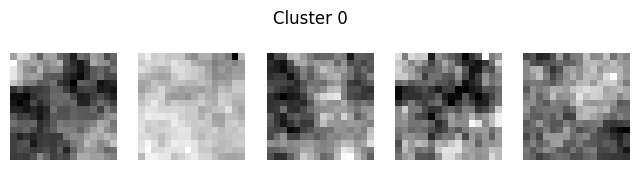

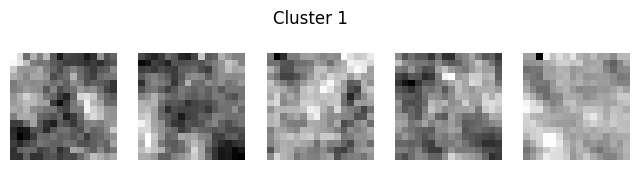

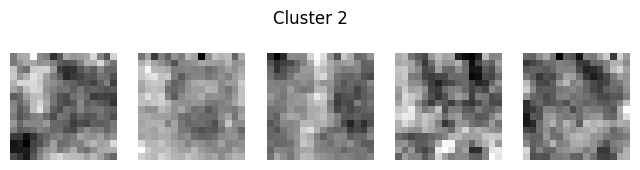

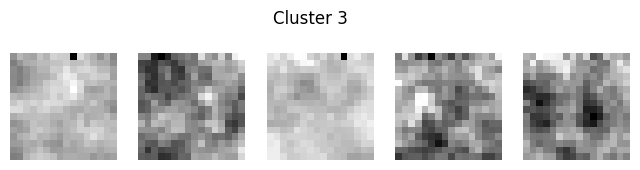

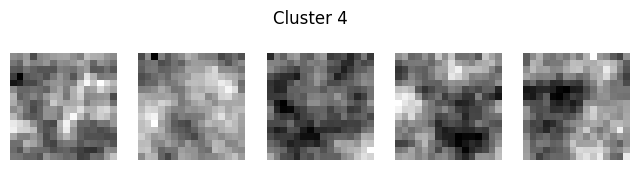

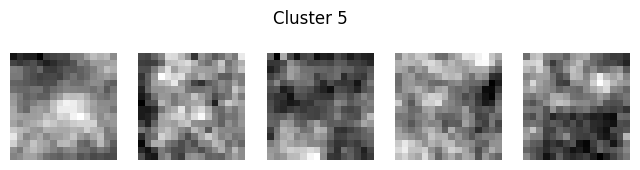

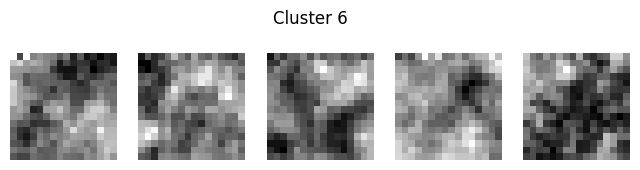

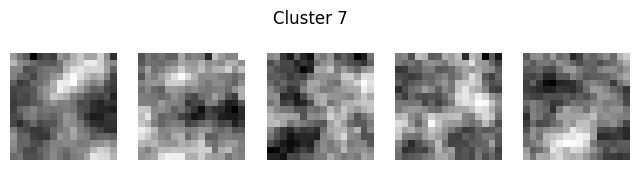

In [15]:
import matplotlib.pyplot as plt

for c in np.unique(labels):
    idx = np.where(labels == c)[0][:5]
    
    plt.figure(figsize=(8,2))
    for i, j in enumerate(idx):
        plt.subplot(1,5,i+1)
        plt.imshow(patches[j], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Cluster {c}")
    plt.show()

In [20]:
print(len(dgms))

65536


In [ ]:
print(len(d))

In [17]:
import numpy as np
from persim import PersistenceImager

# Initialize persistence imager
pimgr = PersistenceImager(pixel_size=0.12)
pimgr.fit(np.array([[0,0]]))  # dummy fit

# Map diagrams to cluster
cluster_diagrams = {}
for c in np.unique(labels):
    cluster_diagrams[c] = [d for d, lab in zip(dgms, labels) if lab == c]

In [23]:
for c, diag_list in cluster_diagrams.items():
    print(f"Cluster {c}: {len(diag_list)} diagrams")
    if len(diag_list) > 0:
        print(f"  First diagram shape: {diag_list[0].shape}")

Cluster 0: 10295 diagrams
  First diagram shape: (19, 2)
Cluster 1: 6273 diagrams
  First diagram shape: (18, 2)
Cluster 2: 12214 diagrams
  First diagram shape: (21, 2)
Cluster 3: 4818 diagrams
  First diagram shape: (22, 2)
Cluster 4: 7564 diagrams
  First diagram shape: (18, 2)
Cluster 5: 4445 diagrams
  First diagram shape: (16, 2)
Cluster 6: 14969 diagrams
  First diagram shape: (18, 2)
Cluster 7: 4958 diagrams
  First diagram shape: (18, 2)


In [ ]:
from persim import PersistenceImager
import numpy as np

# IMPORTANT:
# Fit on all diagrams first so every image has the same shape
all_points = np.vstack([
    d for diag_list in cluster_diagrams.values()
    for d in diag_list
    if len(d) > 0
])

pimgr = PersistenceImager(pixel_size=0.05)
pimgr.fit(all_points)

cluster_persistence_density = {}

for cluster_id, diag_list in cluster_diagrams.items():

    images = []

    for d in diag_list:
        if len(d) == 0:
            continue

        img = pimgr.transform(d)
        images.append(img)

    if len(images) == 0:
        continue

    cluster_persistence_density[cluster_id] = np.mean(images, axis=0)

In [1]:
import matplotlib.pyplot as plt

n_clusters = len(cluster_persistence_density)

fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))

if n_clusters == 1:
    axes = [axes]

for ax, (cluster_id, density) in zip(
        axes,
        sorted(cluster_persistence_density.items())):

    ax.imshow(density, origin="lower", cmap="magma")
    ax.set_title(f"Cluster {cluster_id}")
    ax.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'cluster_persistence_density' is not defined